In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Project 001 - Titanic EDA

Goal: Determine which passenger characteristics appear to have the strongest relationship with survival during the Titanic disaster.

## 1-Load the data

In [2]:
df = pd.read_csv("../data/raw/train.csv")

df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2-Dataset overview
In this section we inspect the dataset dimensions, distribution of its features, and missing values before performing the analysis.

In [3]:
print(f"Dataframe dimensions: {df.shape}")

print(df.isna().sum())

missing = (
    df.isna()
    .mean()
    .mul(100)
    .round(1)
    .sort_values(ascending=False)
)
missing

Dataframe dimensions: (891, 12)
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


Cabin          77.1
Age            19.9
Embarked        0.2
PassengerId     0.0
Name            0.0
Pclass          0.0
Survived        0.0
Sex             0.0
Parch           0.0
SibSp           0.0
Fare            0.0
Ticket          0.0
dtype: float64

Over 77% of Cabin and nearly 20% of Age are missing. Only 2 values are missing in embarked.

Percentage of passengers who survived: 38.4 %


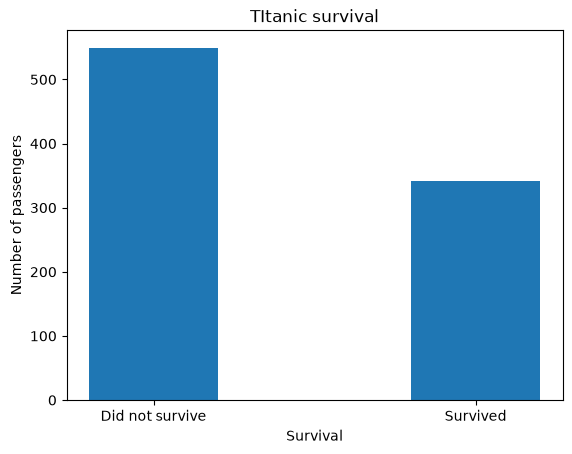

In [4]:
# Survival distribution
survived_counts = df["Survived"].value_counts().sort_index()

plt.bar(survived_counts.index, survived_counts.values, width=0.4)
plt.xticks([0, 1], ["Did not survive", "Survived"])
plt.xlabel("Survival")
plt.ylabel("Number of passengers")
plt.title("TItanic survival")

print(f"Percentage of passengers who survived: {(survived_counts.values[1] / len(df) * 100).round(1)} %")

**Observation**

In our dataset, approximately 38 % of passengers survived, while 62 % did not. This indicate that the dataset is moderately imbalanced but still suitable for analysis.

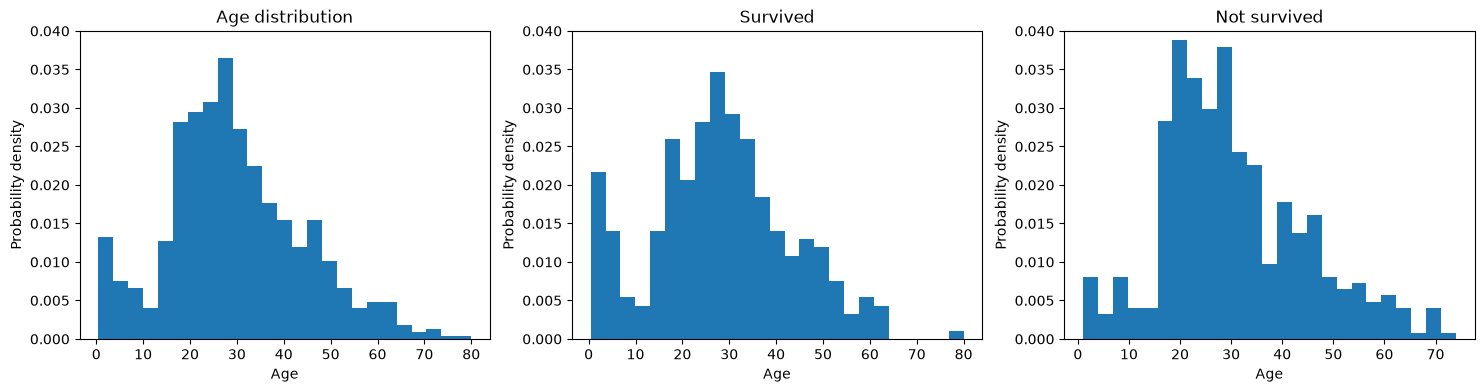

In [5]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(18, 4))

axs[0].hist(df["Age"], bins=25, density=True)
axs[0].set_title("Age distribution")

axs[1].hist(df.loc[df["Survived"] == 1, "Age"], bins=25, density=True)
axs[1].set_title("Survived")


axs[2].hist(df.loc[df["Survived"] == 0, "Age"], bins=25, density=True)
axs[2].set_title("Not survived")


for ax in axs:
    ax.set_xlabel("Age")
    ax.set_ylabel("Probability density")
    #ax.set_ylim(0, 85)
    ax.set_ylim(0, 0.04)


**Observation**

The age distribution is only based on the 80% of passengers for whom age information is available, as 20% of age information is missing. The histograms were plotted using density=True. It means that the y-axis represents a probability density instead of passenger count. This normalization allows us to compare the shape of the age distribution for survivors and non-survivors, despite the unequal sizes of the two groups. The normalized histograms suggest that children represent a larger proportion of survivors than non-survivors. Conversely, adults appear to make a larger proportion of the non-survivors. Very few passengers were over 65 years old, making it difficult to draw strong conclusions for seniors.

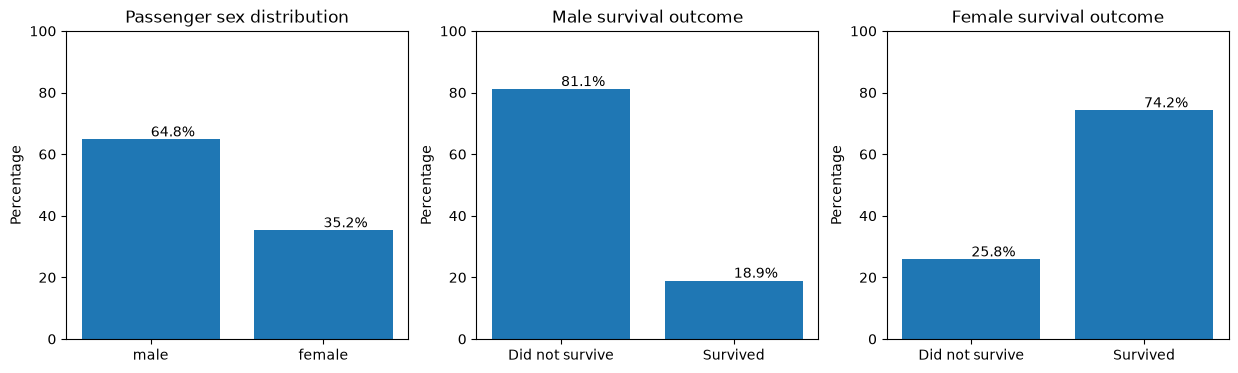

In [6]:
# Male/female distribution

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(15, 4))
sex_count = df["Sex"].value_counts()

axs[0].bar(sex_count.index, sex_count.values/len(df)*100)
axs[0].set_title("Passenger sex distribution")

male_total = (df["Sex"] == "male").sum()
female_total = (df["Sex"] == "female").sum()


survival_by_sex = pd.crosstab(df["Sex"], df["Survived"])

axs[1].bar(["Did not survive", "Survived"], survival_by_sex.loc["male"]/male_total*100)
axs[2].bar(["Did not survive", "Survived"], survival_by_sex.loc["female"]/female_total*100)
 
axs[1].set_title("Male survival outcome")
axs[2].set_title("Female survival outcome")

for ax in axs:
    ax.set_ylabel("Percentage")
    ax.set_ylim(0,100)

    for bar in ax.patches:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 1,
            f"{height.round(1)}%"
        )



**Observation**

The distribution of passenger sex is imbalanced, with approximately 65% of passengers being males. The survival rate was of 18.9% for male passengers, compared whith 74.2% for female passengers. This difference suggests that passenger sex was strongly correlated with survival. One possible explanation is the "women and children first" evacuation policy, which may have given female passengers and young children priority during the evacuation.

Pclass          1         2         3
Survived                             
0         0.37037  0.527174  0.757637
1         0.62963  0.472826  0.242363


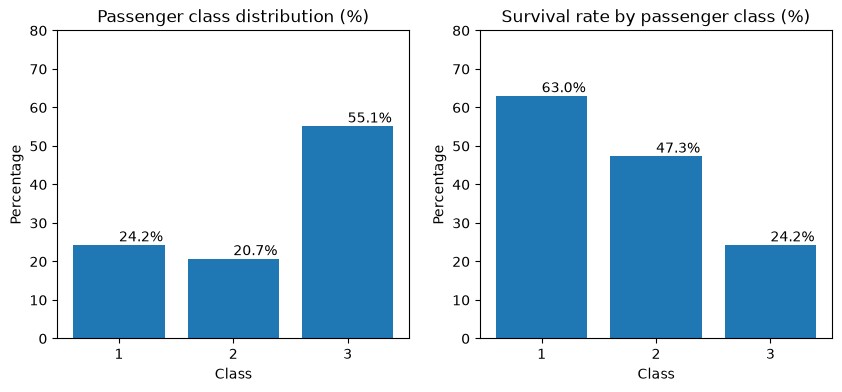

In [7]:
# Bar plot of survival versus passenger class

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))


class_count = df["Pclass"].value_counts()
survival_by_class = pd.crosstab(df["Survived"], df["Pclass"], normalize="columns")

axs[0].set_title("Passenger class distribution (%)")
axs[1].set_title("Survival rate by passenger class (%)")

axs[0].bar(class_count.index, class_count.values /len(df)*100)

print(survival_by_class)

axs[1].bar(survival_by_class.loc[1].index, survival_by_class.loc[1].values*100)

for ax in axs:
    ax.set_xlabel("Class")
    ax.set_ylabel("Percentage")
    ax.set_xticks([1, 2, 3])
    ax.set_ylim(0, 80)
    
    for bar in ax.patches:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 1,
            f"{height.round(1)}%"
        )

**Observation**
More than half of the passengers travelled in third class, while approximately one quarter travelled in first class. Survival rate decrease markedly with passenger class: 63% of first-class passengers survived, compared with 47.3% of second-class passengers and only 24.2% of third-class passengers. This suggest that passenger class was strongly associated with survival. One possible explanation is that first class passengers had a cabin closer to the boat deck and received priority during the evacuation, allowing them easier access to the lifeboats.

Parch
0    678
1    118
2     80
3      5
4      4
5      5
6      1
Name: count, dtype: int64
Parch            0         1    2    3    4    5    6
Survived                                             
0         0.656342  0.449153  0.5  0.4  1.0  0.8  1.0
1         0.343658  0.550847  0.5  0.6  0.0  0.2  0.0


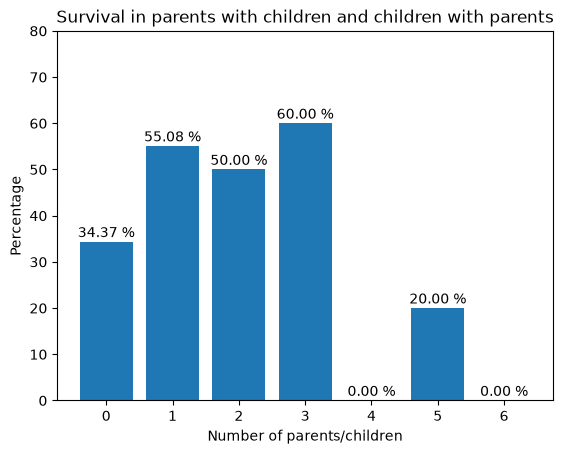

In [8]:
print(df["Parch"].value_counts().sort_index())

survival_by_children = pd.crosstab(df["Survived"], df["Parch"], normalize="columns")
print(survival_by_children)

plt.bar(survival_by_children.loc[1].index, survival_by_children.loc[1].values*100)

ax = plt.gca()
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height+1,
        f"{height:.2f} %",
        ha="center"
    )
plt.ylim(0, 80)
plt.xlabel("Number of parents/children")
plt.ylabel("Percentage")
plt.title("Survival in parents with children and children with parents")
plt.show()

1     537
2     161
3     102
4+     91
Name: count, dtype: int64
col_0     1   2   3  4+
Pclass                 
1       109  70  24  13
2       104  34  31  15
3       324  57  47  63


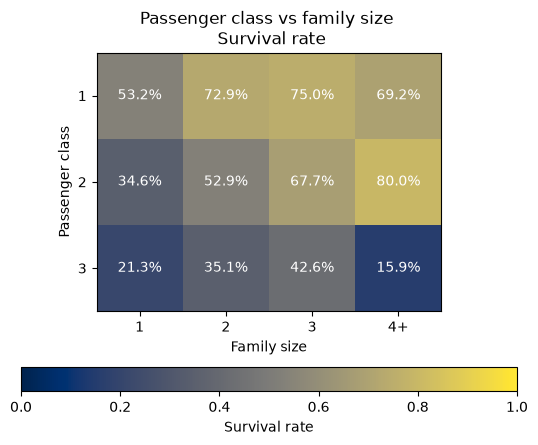

In [13]:

# Create family_sizes dataset by grouping Parch and SibSp columns together. Add one for the corresponding passenger. 
family_size = df["Parch"] + df["SibSp"] + 1

size_labels = ["1", "2", "3", "4+"]

# Group together family sizes with very few data
family_size_groups = pd.cut(family_size, bins=[0, 1, 2, 3, 11], labels=size_labels)
print(family_size_groups.value_counts().sort_index())

print(pd.crosstab(df["Pclass"], family_size_groups))

# Create the 2D grid of data to plot the heatmap
heatmap_data = df.pivot_table(index="Pclass", columns=family_size_groups, values="Survived", aggfunc="mean")


# Plot the heatmap
plt.imshow(
    heatmap_data, 
    cmap="cividis",
    vmax=1,
    vmin=0
    )

# Draw precise percentage over each tile of the heatmap
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        plt.text(
            j,
            i,
            f"{heatmap_data.iloc[i, j]:.1%}", 
            ha='center', 
            va='center', 
            color='white', 
            fontsize=10
            )


# Addition of a colorbar
cbar =plt.colorbar(orientation="horizontal")
cbar.set_label("Survival rate")


plt.xticks(range(heatmap_data.shape[1]), heatmap_data.columns)
plt.yticks(range(heatmap_data.shape[0]), heatmap_data.index)
plt.xlabel("Family size")
plt.ylabel("Passenger class")
plt.title("Passenger class vs family size \n Survival rate")
plt.show()

## 4-Visualize important relationships

## 5-Conclusions